# Comparative Analysis of Regression and Classification Models

## 1. Objective

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

## 2. Regression Results

In [10]:
regression_metrics = pd.read_csv("final_metrics.csv")
validation_comparison = pd.read_csv("validation_comparison.csv")

display(regression_metrics)
display(validation_comparison)

,selected_model,MAE,RMSE,R2
0,Least Squares,13.429266,21.154811,0.552722


,Model,MAE,RMSE,R2
0,Least Squares,15.457204,22.706283,0.480174
1,MLE,15.457204,22.706283,0.480174
2,Ridge (alpha=100),15.563789,22.794376,0.476133
3,Bayesian Regression,15.589996,22.860639,0.473083
4,Ridge (alpha=10),15.593063,22.869861,0.472658
5,Ridge (alpha=0.01),15.593095,22.877971,0.472284
6,Ridge (alpha=1),15.596934,22.881896,0.472102
7,Ridge (alpha=0.1),15.596948,22.882698,0.472065
8,Robust Regression,15.682261,23.517705,0.442358


## 3. Classification Results

In [11]:
classification_analysis = pd.read_csv(
    "classification_analysis.csv"
)

classification_errors = pd.read_csv(
    "classification_error_analysis.csv"
)

display(classification_analysis)
display(classification_errors)

,Metric,Value
0,Accuracy,81.20
1,Storm Precision,22.54
2,Storm Recall,62.75
3,Storm F1,33.16
4,True Positives,96.00
5,False Positives,330.00
6,True Negatives,1575.00
7,False Negatives,57.00


,Error Type,Count
0,True Positive,96
1,False Positive,330
2,True Negative,1575
3,False Negative,57


## 4. Regression vs Classification Comparison

In [12]:
comparison = pd.DataFrame({
    "Task": ["Regression", "Classification"],
    "Target": ["Continuous Dst value", "Storm / Quiet"],
    "Model": ["Least Squares", "XGBoost"],
    "Main Metric": ["RMSE = 21.15 nT", "Storm Recall = 62.75%"],
    "Performance": ["R² = 0.553", "Storm F1 = 33.16%"]
})

display(comparison)

,Task,Target,Model,Main Metric,Performance
0,Regression,Continuous Dst value,Least Squares,RMSE = 21.15 nT,R² = 0.553
1,Classification,Storm / Quiet,XGBoost,Storm Recall = 62.75%,Storm F1 = 33.16%


### Interpretation

Regression predicts the continuous Dst value and therefore provides an estimate of storm intensity. The final Least Squares model achieved an MAE of 13.43 nT, RMSE of 21.15 nT and R² of 0.553 on the test set.

Classification converts Dst into Storm and Quiet classes and focuses on detecting storm events. On the test set, the classifier achieved 62.75% storm recall, meaning it detected 96 out of 153 actual storms. However, its storm precision was only 22.54%, indicating a high number of false alarms.

Therefore, regression is useful for estimating the continuous Dst level, while classification is useful for identifying whether a storm event is likely.

## 5. Error Analysis

In [13]:
display(classification_errors)

,Error Type,Count
0,True Positive,96
1,False Positive,330
2,True Negative,1575
3,False Negative,57


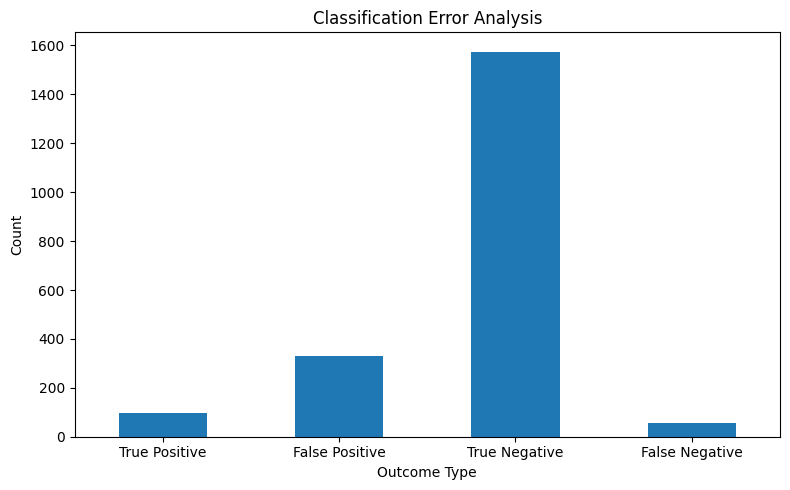

In [14]:
classification_errors.plot(
    x="Error Type",
    y="Count",
    kind="bar",
    legend=False,
    figsize=(8,5)
)

plt.title("Classification Error Analysis")
plt.xlabel("Outcome Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Limitations

- The validation dataset contains no actual storm events, so its 94.27% accuracy is not representative of storm-detection performance.
- The test classification results show a high number of false positives.
- The classification dataset is highly imbalanced between Quiet and Storm classes.
- Regression and classification solve different prediction tasks, so their metrics should not be directly treated as equivalent.
- Feature importance indicates model influence but does not prove physical causation.

## 9. Conclusion

The comparative analysis shows that regression and classification provide complementary information for geomagnetic storm forecasting. Regression estimates the continuous Dst value, while classification focuses on identifying storm events. The regression model achieved an R² of 0.553 with an MAE of 13.43 nT, whereas the classification model detected 62.75% of actual storms but produced many false alarms. Combining continuous Dst estimation with storm-event classification can therefore provide a more informative forecasting framework.